# GloFAS v4 vs v5 (and all sources): magnitude bias vs observed discharge

Notebook version of `scripts/compare_glofas_versions.py` (results first
computed 2026-08-01/03). Bias of each model's daily discharge against the
real observed discharge scraped from the SNRFA station pages (EF5 work;
blob `ds-aa-som-floods/raw/ef5/analysis/*_real_discharge.json`) at the four
stations that publish it. Observed discharge is a deterministic rating
transform of level and caps at bank-full, so high-quantile ratios are UPPER
bounds on model underestimation.

In [1]:
import sys

sys.path.insert(0, "..")

import json as _json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, NullFormatter
import ocha_stratus as stratus

from src.constants import (
    SEASONS,
    SEASON_MONTHS,
    EXP_SEASONS,
    STATIONS,
    INK,
    BODY,
    FAINT,
    GRID,
    C_MOD,
    C_HIGH,
    C_GU,
    C_DEYR,
    C_JUBA,
    C_SHAB,
    C_MAIN,
    C_ISOL,
    C_JOINT,
    C_BAND,
    C_BAND_EDGE,
    C_REF,
    C_GEOGLOWS,
    C_GOOGLE,
    C_GLOFAS4,
    C_GLOFAS5,
    C_SWALIM,
    C_SFED,
    SOURCE_COLORS,
)
from src.plots import apply_chart_style, style_ax
from src.utils import (
    auc,
    episodes,
    gumbel_rp,
    hits,
    weibull_level,
    weibull_threshold,
    yT,
)

apply_chart_style()


In [2]:
SOURCES = ["geoglows", "google_grrr", "glofas_v4", "glofas_v5"]
dd = pd.concat([
    stratus.load_parquet_from_blob(f"ds-aa-som-floods/processed/discharge_daily_{s}.parquet", stage="dev")
    for s in SOURCES], ignore_index=True)
dd["date"] = pd.to_datetime(dd["date"])
OBS = {"belet_weyne": "beletweyne", "bulo_burti": "buloburte", "luuq": "luuq", "bardheere": "bardheere"}
rows = []
for key, slug in OBS.items():
    o = pd.Series(_json.loads(stratus.load_blob_data(
        f"ds-aa-som-floods/raw/ef5/analysis/{slug}_real_discharge.json", stage="dev")), dtype=float)
    o.index = pd.to_datetime(o.index); o = o.sort_index().dropna()
    for src in dd.source.unique():
        m = dd[(dd.source == src) & (dd.station == key)].set_index("date")["discharge"]
        j = pd.concat([m, o], axis=1, join="inner").dropna(); j.columns = ["mod", "obs"]
        j = j[j.obs > 0]
        if len(j) < 500: continue
        am = j.resample("YE").max().dropna()
        rows.append({"station": key, "source": src, "n_days": len(j),
                     "median_ratio": j["mod"].median()/j["obs"].median(),
                     "q95_ratio": j["mod"].quantile(.95)/j["obs"].quantile(.95),
                     "annual_max_ratio": (am["mod"]/am["obs"]).median(),
                     "spearman": j["mod"].corr(j["obs"], method="spearman")})
bias = pd.DataFrame(rows)
for metric in ["median_ratio", "annual_max_ratio", "spearman"]:
    print(f"=== {metric} ===")
    print(bias.pivot(index="station", columns="source", values=metric).round(2).to_string())
    print()


=== median_ratio ===
source       geoglows  glofas  glofas_v5  google
station                                         
bardheere        0.94    0.61       0.13    0.07
belet_weyne      6.29    3.91       0.96    1.24
bulo_burti       7.34    5.46       0.81    1.33
luuq             5.71    4.22       0.99    0.58

=== annual_max_ratio ===
source       geoglows  glofas  glofas_v5  google
station                                         
bardheere        1.70    0.76       0.31    0.15
belet_weyne      9.26    2.80       1.08    0.82
bulo_burti      11.44    3.67       1.22    1.04
luuq             4.59    1.93       0.86    0.44

=== spearman ===
source       geoglows  glofas  glofas_v5  google
station                                         
bardheere        0.71    0.81       0.82    0.51
belet_weyne      0.75    0.65       0.77    0.62
bulo_burti       0.76    0.67       0.76    0.66
luuq             0.78    0.82       0.83    0.64



## Bias at a glance

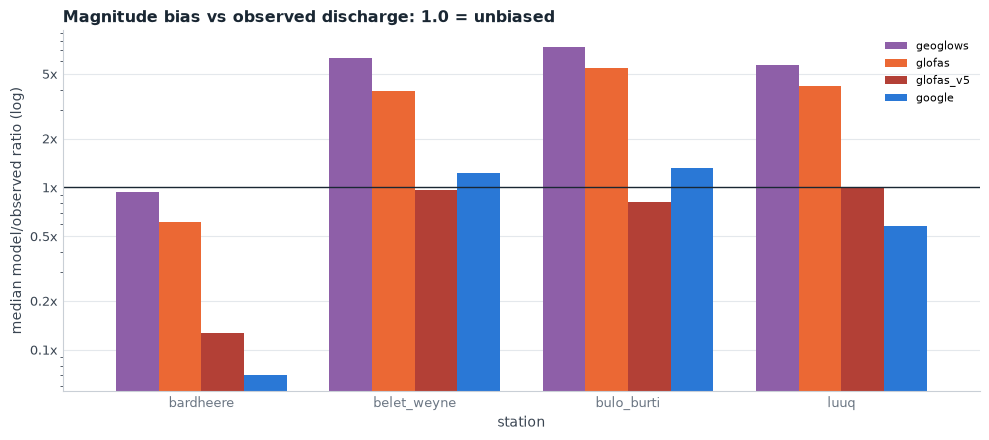

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5))
piv = bias.pivot(index="station", columns="source", values="median_ratio")
piv = piv[
    [
        c
        for c in ["geoglows", "glofas", "glofas_v4", "glofas_v5", "google", "google_grrr"]
        if c in piv.columns
    ]
]
piv.plot.bar(ax=ax, width=0.8, color=[SOURCE_COLORS[c] for c in piv.columns])
ax.axhline(1.0, color=INK, lw=1)
ax.set_yscale("log")
ticks = [0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10]
ax.yaxis.set_major_locator(FixedLocator(ticks))
ax.yaxis.set_major_formatter(lambda v, _: f"{v:g}x")
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_ylabel("median model/observed ratio (log)")
ax.set_title("Magnitude bias vs observed discharge: 1.0 = unbiased")
ax.legend(fontsize=8)
plt.xticks(rotation=0)
style_ax(ax, grid="y")
plt.tight_layout()


## Verdict

- **GloFAS v5 essentially fixes v4's wet bias** (Belet Weyne 3.9x -> ~1.0x;
  Bulo Burti 5.5x -> ~0.9x; Luuq 4.2x -> ~1.0x) and improves rank correlation
  at all four stations: better in magnitude AND timing.
- **GRRR is the other near-unbiased source** (1.2-1.3x on the Shabelle).
- **GEOGloWS is the wettest** (5.7-7.4x median on Shabelle/Luuq).
- **Bardheere: every source runs dry** (v5 0.13x, GRRR 0.07x): with three
  independent models disagreeing with the gauge the same way, suspect the
  observation (gauge history known to be messy; destroyed Nov 2023).
- **Trade-off**: v5 has NO reforecast on EWDS (archive stops at v4): so
  calibrate forecast triggers on v4 via return periods (implicit frequency
  correction), use v5 where absolute magnitudes matter.